# Word2Vec training

This notebook is based on the [word2vec-pytorch](https://github.com/OlgaChernytska/word2vec-pytorch/tree/18d4f24c4d82dde76de9f6e4d88bbcbcf68befc2) repo.

In [ ]:
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.train.tokens
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.valid.tokens

In [ ]:
# !pip install nltk seaborn matplotlib gensim

У торча есть библиотека torchtext для работе с текстами, но она deprecated (и на багованно ставится), поэтому возьмем `nltk`

In [5]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader

# from torchtext.data.utils import get_tokenizer  # Buggy
# from torchtext.vocab import build_vocab_from_iterator  # Buggy


from nltk.tokenize import WordPunctTokenizer


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

In [6]:
TRAIN_TOKENS = './wiki.train.tokens'
VALID_TOKENS = './wiki.valid.tokens'

SKIPGRAM_N_WORDS = 4
MIN_WORD_FREQUENCY = 20
MAX_SEQUENCE_LENGTH = 256

EMBED_DIM = 256
EMBED_MAX_NORM = 1
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [4]:
import torch

In [7]:
tokens = torch.tensor([1, 2, 2, 3, 2, 4, 0, 0])
tokens

tensor([1, 2, 2, 3, 2, 4, 0, 0])

In [17]:
import torch.nn as nn


emb = nn.Embedding(6, 16, padding_idx=0)

emb.weight

Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.1146, -1.7211,  1.1852, -0.3720, -0.5107,  0.2487, -1.4903, -2.8400,
          0.8474,  0.1504, -0.9604, -0.2690,  0.6772, -1.6003,  1.1172, -0.3261],
        [-0.0948,  0.4652, -0.5580, -0.6511, -0.4795, -0.1076, -1.1751, -0.5257,
          1.1855, -0.2639,  0.0530, -0.5809,  0.5650, -0.3950, -1.2882,  1.3781],
        [-0.6703, -1.0536,  0.2482,  0.0076,  0.0728,  0.9610,  0.9625, -1.6720,
          2.0272, -0.6674, -0.4473,  2.2989, -1.9305, -0.0544,  0.1922,  2.2785],
        [-0.1409,  2.1157,  0.1196, -0.1626,  0.3885,  2.1813, -0.7065, -0.3159,
          0.6994, -2.0671, -1.1982, -0.7977,  0.5236,  0.0099, -0.6153,  0.1957],
        [ 0.1768, -0.0103, -0.6103, -2.1175, -0.1337,  0.1133,  0.9845, -0.7902,
          0.0353,  1.3539,  0.8781, -0.5689,  0.7228,  0.4480,  0.2372, -0.5092]],

In [11]:
embeds = emb(tokens)

In [18]:
embeds

tensor([[-0.8565, -0.4652,  1.5586,  0.4096, -0.3991,  0.2398,  0.1682,  1.6317,
         -0.7108,  0.5431, -0.5989, -0.3547, -0.5126, -0.0085,  1.4887,  0.3998],
        [-1.0728, -0.1586, -1.5351,  0.6974,  0.4066,  1.1254,  0.0646, -0.1084,
          1.4041,  0.4658,  1.5271, -1.5746,  0.2868,  0.5801, -0.0704,  0.7635],
        [-1.0728, -0.1586, -1.5351,  0.6974,  0.4066,  1.1254,  0.0646, -0.1084,
          1.4041,  0.4658,  1.5271, -1.5746,  0.2868,  0.5801, -0.0704,  0.7635],
        [-0.4783, -1.6318,  1.8671,  1.1910, -0.6888, -0.2395,  0.5118, -1.0677,
         -0.3374, -0.6925, -0.4096,  1.2963, -1.6099, -1.0204, -0.5718,  1.0503],
        [-1.0728, -0.1586, -1.5351,  0.6974,  0.4066,  1.1254,  0.0646, -0.1084,
          1.4041,  0.4658,  1.5271, -1.5746,  0.2868,  0.5801, -0.0704,  0.7635],
        [ 0.1870, -0.8915, -1.4945, -0.9313,  0.3436,  0.2164,  0.3995, -0.9428,
         -1.2836,  0.4537,  0.0077, -0.1759,  1.5162,  0.7650, -1.0625,  1.3587],
        [ 0.0000,  0.0

In [15]:
for t, e in zip(tokens, embeds):
    print(f"token_i={t}, {torch.allclose(emb.weight[t], e)}")

token_i=1, True
token_i=2, True
token_i=2, True
token_i=3, True
token_i=2, True
token_i=4, True
token_i=0, True
token_i=0, True


In [7]:
tokenizer = WordPunctTokenizer()

In [9]:

def load_and_preprocess_dataset(path):
    with open(path, 'r') as file:
        lines = file.readlines()

    data = list(filter(
        lambda sent: len(sent) > SKIPGRAM_N_WORDS * 2,
        map(tokenizer.tokenize, lines)
    ))
    return data

In [10]:
train_data = load_and_preprocess_dataset(TRAIN_TOKENS)
valid_data = load_and_preprocess_dataset(VALID_TOKENS)

total_train_tokens = sum(len(sent) for sent in train_data)
total_valid_tokens = sum(len(sent) for sent in valid_data)

print(f'Num sentences: train - {len(train_data)}, valid - {len(valid_data)}')
print(f'Total tokens: train - {total_train_tokens}, valid - {total_valid_tokens}')
print(f'Average tokens in sentence: {total_train_tokens / len(train_data):.2f}')

Num sentences: train - 18251, valid - 1969
Total tokens: train - 2149387, valid - 236601
Average tokens in sentence: 117.77


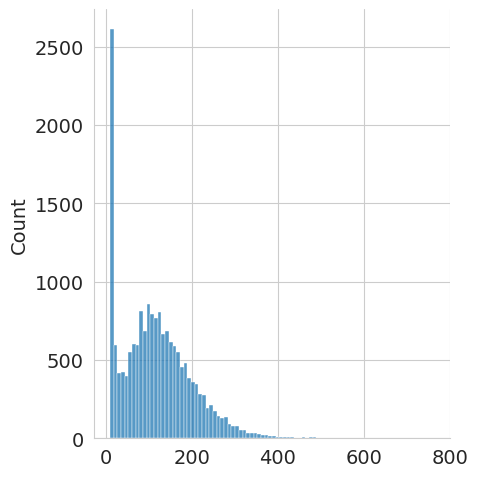

In [11]:
_ = sns.displot([len(sent) for sent in train_data])

In [12]:
from itertools import chain

from typing import Iterable, Union

In [13]:
from collections import Counter
from operator import itemgetter

In [14]:
class VocabPseudoVectorized:
    def __init__(self, train_data: Iterable[str],
                 unk_label: str = "<UNK>",
                 unk_cutoff: int = MIN_WORD_FREQUENCY):
        raw_counts = Counter(train_data)
        for token, frequency in tuple(raw_counts.items()):
            if frequency >= unk_cutoff:
                continue
            raw_counts.pop(token)
        remaining_tokens = list(raw_counts.keys())
        # add UNK token:
        remaining_tokens[0:0] = [unk_label]

        self._token2idx = {
            token: id_ for id_, token in enumerate(remaining_tokens)
        }
        self._idx2token = {
            id_: token for id_, token in enumerate(remaining_tokens)
        }

    def _fetch_index(self, item: str):
        return self._token2idx.get(item, 0)  # <--- UNK token

    def __getitem__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        if isinstance(item, Iterable) and not isinstance(item, str):
            return list(map(self.__getitem__, item))
    
        return self._fetch_index(item)

    def __call__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        return self[item]

    def __len__(self, ):
        return len(self._token2idx)

    def __contains__(self, item):
        return item in self._token2idx

    def lookup(self, item: Union[str, Iterable[str]]):
        result = []
        if isinstance(item, str):
            return self[item]
        for x in item:
            result.append(self.lookup(x))
        return result

    def get_itos(self, items: Iterable[str]):
        if isinstance(items, torch.Tensor):
            items = items.detach().cpu().tolist()
        return [self._idx2token[i] for i in items]

In [15]:
vocab = VocabPseudoVectorized(chain(*train_data))

VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Vocab size: 8716


In [16]:
train_data[102]

['National',
 'Mission',
 ';',
 'Society',
 'for',
 'the',
 'Preservation',
 'of',
 'Christian',
 'Knowledge',
 ',',
 '1916']

In [19]:
train_data[123]

['Flower', 'Fairies', 'of', 'the', 'Trees', ';', 'Blackie', ',', '1940']

In [18]:
vocab[train_data[123]]

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [21]:
vocab.get_itos(vocab[train_data[123]]) == train_data[123]  # Правдиво только если не встретится неизвестный токен

True

In [23]:
vocab[train_data[123]]

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [22]:
vocab.get_itos(vocab[train_data[123]])

['Flower', 'Fairies', 'of', 'the', 'Trees', ';', 'Blackie', ',', '1940']

In [24]:
vocab.lookup(train_data[123])

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [25]:
vocab.lookup(["ASDASD", "asdaa", ["cat", "dog"]])

[0, 0, [4016, 3902]]

In [26]:
vocab["Mission"]

1867

In [27]:
vocab["<UNK>"]

0

In [28]:
vocab[train_data[102]]

[1478, 1867, 373, 1620, 36, 15, 0, 14, 1546, 0, 11, 1832]

In [29]:
vocab(train_data[102])

[1478, 1867, 373, 1620, 36, 15, 0, 14, 1546, 0, 11, 1832]

In [30]:
vocab("cat")

4016

In [31]:
vocab("13123123123")

0

In [33]:
def collate_fn(batch):
    """
    # T_1, T_2, T_3, T_4
    Collate_fn for Skip-Gram model to be used with Dataloader.
    `batch` is expected to be list of text paragrahs.

    Context is represented as N=SKIPGRAM_N_WORDS past words 
    and N=SKIPGRAM_N_WORDS future words.

    Long paragraphs will be truncated to contain
    no more that MAX_SEQUENCE_LENGTH tokens.

    Each element in `batch_input` is a middle word.
    Each element in `batch_output` is a context word.
    """
    batch_input, batch_output = [], []
    for text in batch:
        text_tokens_ids = vocab(text)

        if MAX_SEQUENCE_LENGTH:
            text_tokens_ids = text_tokens_ids[:MAX_SEQUENCE_LENGTH]

        for idx in range(len(text_tokens_ids) - SKIPGRAM_N_WORDS * 2):
            token_id_sequence = text_tokens_ids[idx : (idx + SKIPGRAM_N_WORDS * 2 + 1)]
            input_ = token_id_sequence.pop(SKIPGRAM_N_WORDS)
            outputs = token_id_sequence

            batch_input += [input_] * len(outputs)
            batch_output += outputs

    batch_input = torch.tensor(batch_input, dtype=torch.long)
    batch_output = torch.tensor(batch_output, dtype=torch.long)
    return batch_input, batch_output

In [34]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, collate_fn=collate_fn, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, collate_fn=collate_fn)

In [38]:
from IPython.display import clear_output
from tqdm.notebook import tqdm


def plot_losses(train_losses, valid_losses):
    clear_output()
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='valid', color='springgreen', linewidth=2)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

In [39]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, num_batches = 0.0, 1
    model.train()
    for inputs, outputs in tqdm(train_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss, num_batches = 0.0, 0
    model.eval()
    for inputs, outputs in tqdm(valid_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        logits = model(inputs)
        loss = criterion(logits, outputs)

        valid_loss += loss.item()
        num_batches += 1

    valid_loss /= num_batches
    return valid_loss


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs):
    train_losses, valid_losses = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        valid_losses += [valid_loss]
        plot_losses(train_losses, valid_losses)

In [40]:
class Word2VecModel(nn.Module):
    def __init__(self, embed_dim, embed_max_norm, vocab_size):
        super().__init__()
        self.embeds = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim,
                                   max_norm=embed_max_norm)
        self.decoder = nn.Linear(embed_dim, vocab_size)
        
    def forward(self, tokens):
        embeds = self.embeds(tokens)
        logits = self.decoder(embeds)
        return logits

In [41]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [44]:
NUM_EPOCHS = 10

In [45]:
model = Word2VecModel(embed_dim=EMBED_DIM, embed_max_norm=EMBED_MAX_NORM,
                      vocab_size=VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

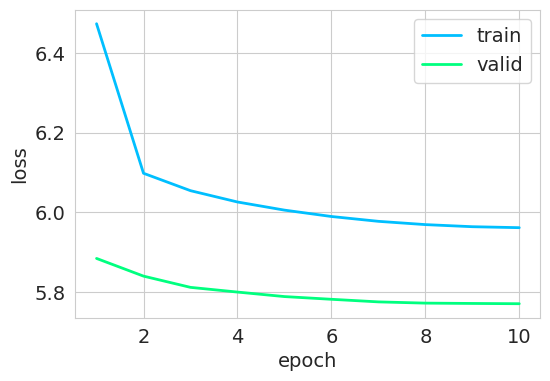

In [46]:
train(model, optimizer, scheduler, criterion, train_loader, valid_loader, NUM_EPOCHS)

In [47]:
embed_matrix = model.embeds.weight.detach()
embed_norms = (embed_matrix ** 2).sum(1).sqrt()

t + s = a

x_t + x_s = x_a

In [48]:
import re


def get_similarities(embed_vector):
    similarities = embed_matrix @ embed_vector / embed_norms / torch.norm(embed_vector)
    top_indices = similarities.argsort(descending=True)
    return similarities, top_indices


def get_similar(query, num_similar=5):
    print(f'Processing query \"{query}\"')
    split_query = re.split('([^a-zA-Z0-9])', query)
    index = vocab[split_query[0]]
    embed_vector = torch.clone(embed_matrix[index])
    if index > 0:
        print(f'Found word \"{split_query[0]}\" in vocab')
    else:
        print(f'Word \"{split_query[0]}\" not in vocab, using <unk>')

    for i in range(2, len(split_query), 2):
        index = vocab[split_query[i]]
        if index > 0:
            print(f'Found word \"{split_query[i]}\" in vocab, ', end='')
        else:
            print(f'Word \"{split_query[i]}\" not in vocab, using <unk>, ', end='')
        print(f'operation \"{split_query[i - 1]}\"')

        if split_query[i - 1] == '+':
            embed_vector += embed_matrix[index]
        elif split_query[i - 1] == '-':
            embed_vector -= embed_matrix[index]
        else:
            raise ValueError('Unknown operation')

    similarities, top_indices = get_similarities(embed_vector)

    itos = vocab.get_itos(top_indices)
    # print('Top similar:')
    # print(itos)
    for top_index in range(num_similar):
        print(f'    {itos[top_index]}: sim = {similarities[top_index]:.4f}')

In [49]:
get_similar('woman')

Processing query "woman"
Found word "woman" in vocab
    woman: sim = 0.4415
    girl: sim = 0.4564
    man: sim = 0.2517
    child: sim = 0.2025
    boy: sim = 0.2324


In [50]:
get_similar('kick')

Processing query "kick"
Found word "kick" in vocab
    kick: sim = 0.3106
    touchdown: sim = 0.2612
    Tech: sim = 0.3205
    ECU: sim = 0.5954
    penalty: sim = 0.2029


In [51]:
get_similar('help')

Processing query "help"
Found word "help" in vocab
    help: sim = 0.3806
    try: sim = 0.4626
    keep: sim = 0.3635
    accept: sim = 0.1723
    escape: sim = 0.1633


In [53]:
v = get_similar('king-man', num_similar=10)

Processing query "king-man"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
    Aviation: sim = 0.0452
    Bureau: sim = -0.1512
    Emperor: sim = 0.1738
    Forces: sim = -0.1587
    Federal: sim = 0.0607
    Clair: sim = 0.0892
    Revolutionary: sim = 0.0698
    Office: sim = 0.0471
    Board: sim = 0.2300
    Education: sim = 0.0279


In [52]:
v = get_similar('king-man+woman', num_similar=10)

Processing query "king-man+woman"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
Found word "woman" in vocab, operation "+"
    king: sim = 0.4282
    Catherine: sim = 0.2835
    Palmyra: sim = 0.3632
    Lord: sim = 0.0521
    Trujillo: sim = 0.2551
    saint: sim = 0.5028
    narrator: sim = 0.4689
    poem: sim = 0.4236
    reincarnation: sim = 0.3863
    Keats: sim = 0.1738


In [54]:
get_similar('king')

Processing query "king"
Found word "king" in vocab
    king: sim = 0.4986
    King: sim = 0.3278
    Odaenathus: sim = 0.3864
    queen: sim = 0.0884
    Lord: sim = 0.2652


## Gensim

Обучим Word2Vec с помощью библиотеки gensim

In [ ]:
# !pip install gensim

In [55]:
from gensim.models import Word2Vec
model = Word2Vec(train_data, 
                 vector_size=32,      # embedding vector size
                 min_count=5,  # consider words that occured at least 5 times
                 window=5).wv  # define context as a 5-word window around the target word

In [59]:
dir(model)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adapt_by_suffix',
 '_load_specials',
 '_log_evaluate_word_analogies',
 '_save_specials',
 '_smart_save',
 '_upconvert_old_d2vkv',
 '_upconvert_old_vocab',
 'add_lifecycle_event',
 'add_vector',
 'add_vectors',
 'allocate_vecattrs',
 'closer_than',
 'cosine_similarities',
 'distance',
 'distances',
 'doesnt_match',
 'evaluate_word_analogies',
 'evaluate_word_pairs',
 'expandos',
 'fill_norms',
 'get_index',
 'get_mean_vector',
 'get_normed_vectors',
 'get_vecattr',
 'get_vector',
 'has_index_for',
 'index2entity',
 'index2word',
 'index_to_key',
 'init_sims',
 

In [62]:
vector = model.word_vec("king") - model.word_vec("man") + model.word_vec("woman")

/tmp/ipykernel_25362/1811656017.py:1: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  vector = model.word_vec("king") - model.word_vec("man") + model.word_vec("woman")


In [63]:
model.most_similar_to_given(vector)

TypeError: most_similar_to_given() missing 1 required positional argument: 'keys_list'

In [56]:
model.most_similar('woman')


[('girl', 0.9501944780349731),
 ('man', 0.9145995378494263),
 ('child', 0.9102222919464111),
 ('boy', 0.8745478987693787),
 ('young', 0.8697184920310974),
 ('relationship', 0.8668877482414246),
 ('person', 0.8576272130012512),
 ('hero', 0.8354681730270386),
 ('spirit', 0.8342589735984802),
 ('baby', 0.8285106420516968)]

In [57]:
model.most_similar('cat')


[('Hypacrosaurus', 0.9285966753959656),
 ('mycorrhizal', 0.9276860356330872),
 ('bone', 0.9275731444358826),
 ('minerals', 0.9267874956130981),
 ('oxide', 0.9216557741165161),
 ('hollow', 0.921116292476654),
 ('giant', 0.9210016131401062),
 ('eating', 0.9180625081062317),
 ('sulfur', 0.9179360866546631),
 ('puma', 0.9112451076507568)]

# FastText for sentiment classification

In [ ]:
%%bash
kaggle datasets download -d shivkumarganesh/bumble-dating-app-google-play-store-review
unzip bumble-dating-app-google-play-store-review.zip

In [ ]:
# !pip install fasttext

In [64]:
import pandas as pd
import fasttext
import fasttext.util

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

In [65]:
data = pd.read_csv('bumble_google_play_reviews.csv')
data = data[data.content.notna()]
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,46c9a193-8a71-428c-8323-b0670593fce4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the app is okay but I highly don't recommend a...,3,0,5.396.0,2024-12-01 00:17:10,All of our core features are free to use. You ...,2024-12-01 04:11:48,5.396.0
1,3e4d396d-8a53-4fee-851a-5657715263cb,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I am 31. Entered my birth date. Yet zero suppo...,1,1,5.396.0,2024-11-30 22:50:15,"We are very sorry to hear about that, Shafiq. ...",2024-12-01 07:20:17,5.396.0
2,bef31ccc-0d63-430f-ac42-1dfc4ac4785d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,cool app,4,0,5.396.0,2024-11-30 22:13:21,Thanks for your kind words. Your feedback is s...,2024-12-01 03:41:17,5.396.0
3,4520d795-a961-4797-af56-2a056d6b16de,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The app let's you know that x amount of people...,1,0,5.396.0,2024-11-30 21:46:15,You don't need to spend any money to match wit...,2024-12-01 04:16:18,5.396.0
4,b278a0b0-5bfa-4922-a7f0-9019b62a683e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,i just am tired of paying so much for app,2,0,5.396.0,2024-11-30 21:28:31,All of our core features are free to use. You ...,2024-12-01 04:12:17,5.396.0
...,...,...,...,...,...,...,...,...,...,...,...
160426,61bc7cdc-3085-4631-ac95-d8e42e2e0742,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally here!,5,54,1.0.1,2015-12-01 02:17:24,NaN,NaN,1.0.1
160427,24d07489-88ad-496a-80ce-8f137c130323,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally!,5,75,1.0.1,2015-12-01 02:09:05,NaN,NaN,1.0.1
160428,22a42d0d-7a12-400d-a2af-826f35d21581,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Finally, an app where women have to start the ...",4,2,1.0.1,2015-12-01 00:18:53,NaN,NaN,1.0.1
160429,2480a41f-8863-4948-9f83-7d856bd9dc78,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,At last we have Android version!,5,60,1.0.0,2015-11-30 21:27:51,NaN,NaN,1.0.0


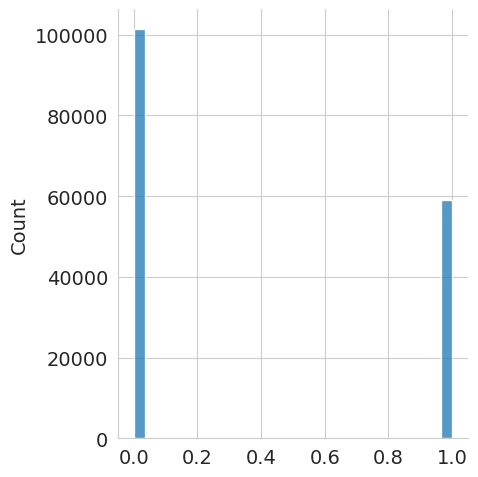

In [66]:
X = data.content.apply(tokenizer.tokenize).to_list()
y = (data.score >= 4).to_numpy().astype(int)
_ = sns.displot(y)

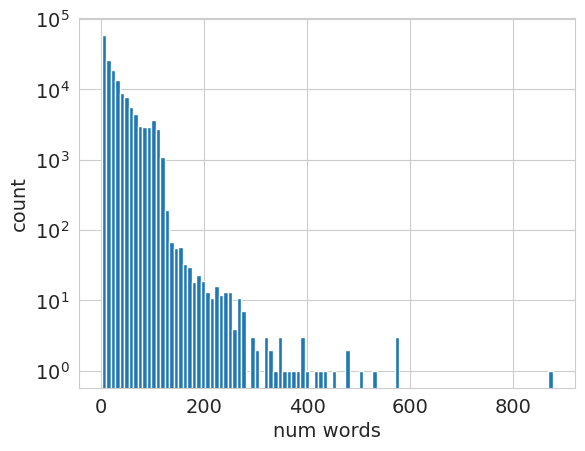

In [67]:
plt.hist([len(sent) for sent in X], bins=100)
plt.yscale('log')
plt.ylabel('count')
plt.xlabel('num words')
plt.show()

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
len(X_train), len(X_test)

(120311, 40104)

In [69]:
fasttext.util.download_model('en', if_exists='ignore')
ft = fasttext.load_model('cc.en.300.bin')

In [70]:
ft.get_word_vector('mother').shape

(300,)

In [71]:
ft.get_nearest_neighbors('mother')

[(0.8316885828971863, 'father'),
 (0.8139842748641968, 'grandmother'),
 (0.8042423725128174, 'daughter'),
 (0.7595430612564087, 'aunt'),
 (0.7551708221435547, 'stepfather'),
 (0.7433159947395325, 'mom'),
 (0.7390366792678833, 'step-father'),
 (0.7379246950149536, 'stepmother'),
 (0.7268661856651306, 'step-mother'),
 (0.7265076041221619, 'sister')]

In [72]:
ft.get_nearest_neighbors('king')

[(0.7550359964370728, 'kings'),
 (0.7068519592285156, 'queen'),
 (0.7060439586639404, 'king-'),
 (0.6811205148696899, 'king.'),
 (0.660710871219635, 'king.The'),
 (0.6591265797615051, 'King'),
 (0.6495252251625061, 'prince'),
 (0.6278106570243835, '-king'),
 (0.6183920502662659, 'monarch'),
 (0.6070184707641602, 'queen-mother')]

In [73]:
emb = ft.get_word_vector('king') - ft.get_word_vector('man') + ft.get_word_vector('woman')


In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [75]:
X_train_sents = [' '.join(sent) for sent in X_train]
X_test_sents = [' '.join(sent) for sent in X_test]

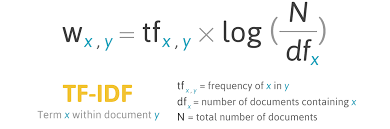

In [76]:
tf_idf = TfidfVectorizer(min_df=5).fit(X_train_sents)
tf_idf_train = tf_idf.transform(X_train_sents)
tf_idf_test = tf_idf.transform(X_test_sents)

tf_idf_train.shape, tf_idf_test.shape

((120311, 9086), (40104, 9086))

In [77]:
lr = LogisticRegression(max_iter=1000).fit(tf_idf_train, y_train)

In [78]:
print(f'Tf-idf + LogRegr train acc: {accuracy_score(lr.predict(tf_idf_train), y_train):.4f}')
print(f'Tf-idf + LogRegr test acc: {accuracy_score(lr.predict(tf_idf_test), y_test):.4f}')

Tf-idf + LogRegr train acc: 0.9022
Tf-idf + LogRegr test acc: 0.8908


In [80]:
def get_sentence_embedding(sent):
    embeds = []
    for word in sent:
        embeds += [ft.get_word_vector(word)]

    return np.stack(embeds, axis=0).mean(0)

In [81]:
train_embeds = np.stack([get_sentence_embedding(sent) for sent in X_train], axis=0)
test_embeds = np.stack([get_sentence_embedding(sent) for sent in X_test], axis=0)

In [82]:
lr = LogisticRegression(max_iter=1000).fit(train_embeds, y_train)

In [83]:
print(f'FastText + LogRegr train acc: {accuracy_score(lr.predict(train_embeds), y_train):.4f}')
print(f'FastText + LogRegr test acc: {accuracy_score(lr.predict(test_embeds), y_test):.4f}')

FastText + LogRegr train acc: 0.8590
FastText + LogRegr test acc: 0.8570


In [84]:
BATCH_SIZE = 128
MAX_SEQUENCE_LENGTH = 256
MODEL_BLOCKS = 2
MODEL_CHANNELS = 300
NUM_EPOCHS = 5

In [85]:
class EmbeddingsDataset(Dataset):
    def __init__(self, sents, targets, max_length):
        super().__init__()
        self.max_length = max_length
        self.sents = sents
        self.targets = targets
    
    def __len__(self):
        return len(self.sents)

    def __getitem__(self, item):
        sent = self.sents[item]
        length = min(len(sent), self.max_length)

        embeds = []
        for word in sent[:length]:
            embeds += [torch.from_numpy(ft.get_word_vector(word).astype(np.float32))]
        
        embeds = torch.stack(embeds, dim=1)
        padding = torch.zeros((embeds.shape[0], self.max_length - length))
        embeds = torch.cat([embeds, padding], dim=1)
        target = self.targets[item]
        return embeds, length, target

In [86]:
train_set = EmbeddingsDataset(X_train, y_train, max_length=MAX_SEQUENCE_LENGTH)
test_set = EmbeddingsDataset(X_test, y_test, max_length=MAX_SEQUENCE_LENGTH)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, num_workers=4,
                          pin_memory=True, shuffle=True, prefetch_factor=4)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, num_workers=4, prefetch_factor=4,
                         pin_memory=True)

In [87]:
class BasicBlock(nn.Module):
    def __init__(self, num_channels, kernel_size):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(num_channels, num_channels, kernel_size,
                               padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(num_channels)
        self.conv2 = nn.Conv1d(num_channels, num_channels, kernel_size,
                               padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(num_channels)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out + x)
        return out

class TextCNN(nn.Module):
    def __init__(self, num_blocks, num_channels, num_classes, kernel_size=5):
        super().__init__()
        self.backbone = nn.Sequential(
            *[BasicBlock(num_channels, kernel_size) for _ in range(num_blocks)]
        )

        self.classifier = nn.Linear(num_channels, num_classes)

    @staticmethod
    def get_lengths_mask(embeds, lengths):
        mask = torch.arange(embeds.shape[-1]).unsqueeze(0).to(embeds.device)
        mask = (mask < lengths.unsqueeze(1)).to(torch.float)
        return mask.unsqueeze(1)

    def forward(self, embeds, lengths):
        # embeds: (B, C, T), lengths: (B, )
        features = self.backbone(embeds)
        # features: (B, C, T)
        mask = self.get_lengths_mask(embeds, lengths)
        # mask: (B, 1, T)
        features = (features * mask).sum(-1) / lengths.unsqueeze(1)
        # features: (B, C)
        logits = self.classifier(features)
        # logits: (B, num_classes)
        return logits

In [88]:
from IPython.display import clear_output
from tqdm.notebook import tqdm


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test', color='springgreen', linewidth=2)
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train',
                color='deepskyblue', linewidth=2)
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test',
                color='springgreen', linewidth=2)
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [89]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for embeds, lengths, labels in tqdm(train_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        embeds = embeds[..., :lengths.max()]

        optimizer.zero_grad()
        logits = model(embeds, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * embeds.shape[0]
        train_accuracy += (logits.argmax(1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss, valid_accuracy = 0.0, 0.0
    model.eval()
    for embeds, lengths, labels in tqdm(valid_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        embeds = embeds[..., :lengths.max()]

        logits = model(embeds, lengths)
        loss = criterion(logits, labels)

        valid_loss += loss.item() * embeds.shape[0]
        valid_accuracy += (logits.argmax(1) == labels).sum().item()

    valid_loss /= len(valid_loader.dataset)
    valid_accuracy /= len(valid_loader.dataset)
    return valid_loss, valid_accuracy


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs):
    train_losses, valid_losses = [], []
    train_accuracies, valid_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss, valid_accuracy = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        valid_losses += [valid_loss]
        valid_accuracies += [valid_accuracy]
        plot_losses(train_losses, valid_losses, train_accuracies, valid_accuracies)

In [90]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [91]:
model = TextCNN(num_blocks=MODEL_BLOCKS, num_channels=MODEL_CHANNELS, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

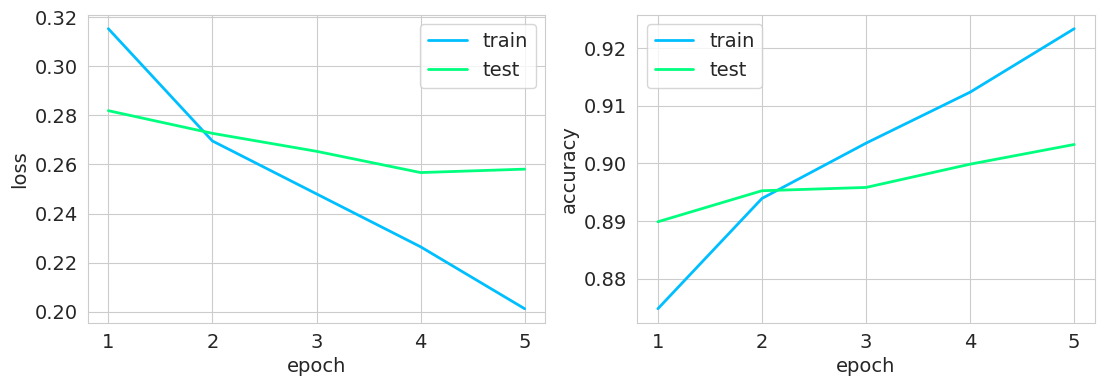

In [92]:
train(model, optimizer, scheduler, criterion, train_loader, test_loader, NUM_EPOCHS)